In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/archive.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/VisDrone_Dataset/VisDrone2019-DET-train/labels/9999951_00000_d_0000236.txt  
  inflating: /content/VisDrone_Dataset/VisDrone2019-DET-train/labels/9999951_00000_d_0000237.txt  
  inflating: /content/VisDrone_Dataset/VisDrone2019-DET-train/labels/9999951_00000_d_0000238.txt  
  inflating: /content/VisDrone_Dataset/VisDrone2019-DET-train/labels/9999951_00000_d_0000239.txt  
  inflating: /content/VisDrone_Dataset/VisDrone2019-DET-train/labels/9999951_00000_d_0000240.txt  
  inflating: /content/VisDrone_Dataset/VisDrone2019-DET-train/labels/9999951_00000_d_0000241.txt  
  inflating: /content/VisDrone_Dataset/VisDrone2019-DET-train/labels/9999951_00000_d_0000242.txt  
  inflating: /content/VisDrone_Dataset/VisDrone2019-DET-train/labels/9999951_00000_d_0000243.txt  
  inflating: /content/VisDrone_Dataset/VisDrone2019-DET-train/labels/9999951_00000_d_0000244.txt  
  inflating: /content/VisDrone_Dataset/VisDrone2019-DET-tr

In [ ]:
!cp -r /content/VisDrone_Dataset /content/drive/MyDrive/

Found 22 objects of class 0 or 1.


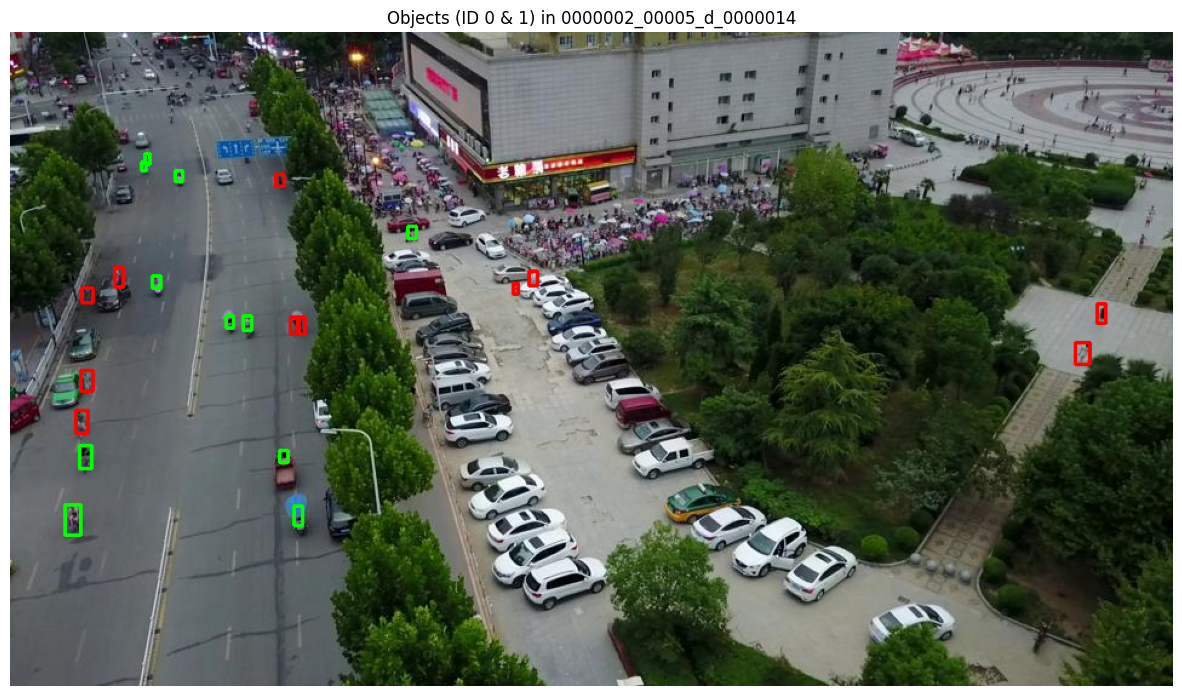

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os
import re

# Define paths for the specific image
base_path = '/content/drive/MyDrive/VisDrone_Dataset/VisDrone2019-DET-train'
image_id = '0000002_00005_d_0000014'
image_path = os.path.join(base_path, f'images/{image_id}.jpg')
label_path = os.path.join(base_path, f'labels/{image_id}.txt')

# Load image
img = cv2.imread(image_path)
if img is None:
    print(f'Error: Could not load image at {image_path}')
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h_img, w_img, _ = img.shape

    # Target categories
    target_ids = [0, 1]
    colors = {0: (255, 0, 0), 1: (0, 255, 0)} # Red for 0, Green for 1
    found_count = 0

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                # Handle both comma and space separated values
                parts = re.split(r'[ ,]+', line.strip())
                if len(parts) < 5: continue

                # Try to detect if it's YOLO format (class first, normalized coords)
                # or VisDrone format (x,y,w,h first, then category)
                try:
                    if '.' in parts[1]: # Likely YOLO format: class x_center y_center width height
                        category = int(float(parts[0]))
                        if category in target_ids:
                            xc, yc, w, h = map(float, parts[1:5])
                            x = int((xc - w/2) * w_img)
                            y = int((yc - h/2) * h_img)
                            bw, bh = int(w * w_img), int(h * h_img)
                            found_count += 1
                            cv2.rectangle(img, (x, y), (x + bw, y + bh), colors[category], 2)
                    else: # Likely VisDrone format: x,y,w,h,score,category,...
                        x, y, bw, bh = map(int, parts[:4])
                        category = int(parts[5])
                        if category in target_ids:
                            found_count += 1
                            cv2.rectangle(img, (x, y), (x + bw, y + bh), colors[category], 2)
                except (ValueError, IndexError):
                    continue
        print(f'Found {found_count} objects of class 0 or 1.')
    else:
        print(f'Label file not found: {label_path}')

    plt.figure(figsize=(15, 10))
    plt.imshow(img)
    plt.title(f'Objects (ID 0 & 1) in {image_id}')
    plt.axis('off')
    plt.show()

// SO both class 0 and class 1 means human . We can merge class 0 and 1 as class separation for these two is weak also we need to count human that includes both pedestrian and people

In [ ]:
!mkdir -p /content/drive/MyDrive/safe
!cp -r /content/drive/MyDrive/VisDrone_Dataset /content/drive/MyDrive/safe/

In [ ]:
from pathlib import Path

def complete_merge(dataset_root):
    root = Path(dataset_root)
    # Mapping: merge 0 & 1 into 0, and shift others down to keep IDs contiguous
    mapping = {0: 0, 1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7, 9: 8, 10: 9}

    modified_count = 0
    for label_file in root.rglob('*.txt'):
        # Ensure we are only touching files in 'labels' directories
        if 'labels' not in str(label_file):
            continue

        with open(label_file, 'r') as f:
            lines = f.readlines()

        new_lines = []
        for line in lines:
            parts = line.split()
            if parts:
                try:
                    old_id = int(float(parts[0]))
                    # Apply mapping if ID exists, else keep as is
                    new_id = mapping.get(old_id, old_id)
                    parts[0] = str(new_id)
                    new_lines.append(" ".join(parts) + "\n")
                except (ValueError, IndexError):
                    new_lines.append(line)

        with open(label_file, 'w') as f:
            f.writelines(new_lines)
        modified_count += 1

    return modified_count

# Using a raw string (r'') as suggested
dataset_path = r'/content/drive/MyDrive/VisDrone_Dataset'
print(f"Starting merge and remap in {dataset_path}...")
total = complete_merge(dataset_path)
print(f"Finished! Processed {total} label files.")

Starting merge and remap in /content/drive/MyDrive/VisDrone_Dataset...
Finished! Processed 8629 label files.


// Now we need to update the .yaml . doing it manually

In [ ]:
from pathlib import Path

def count_dataset_files(root_path):
    root = Path(root_path)
    splits = ['VisDrone2019-DET-train', 'VisDrone2019-DET-val', 'VisDrone2019-DET-test-dev']

    # First, calculate total images to get percentages
    all_images = []
    for split in splits:
        all_images.extend(list((root / split / 'images').glob('*.jpg')))
    total_imgs = len(all_images)

    print(f"{'Split':<30} | {'Images':<10} | {'%':<6} | {'Labels':<10}")
    print("-" * 65)

    for split in splits:
        split_path = root / split
        if not split_path.exists():
            continue

        img_count = len(list((split_path / 'images').glob('*.jpg')))
        lbl_count = len(list((split_path / 'labels').glob('*.txt')))
        percentage = (img_count / total_imgs * 100) if total_imgs > 0 else 0

        print(f"{split:<30} | {img_count:<10} | {percentage:>5.1f}% | {lbl_count:<10}")

dataset_root = '/content/drive/MyDrive/VisDrone_Dataset'
count_dataset_files(dataset_root)

Split                          | Images     | %      | Labels    
-----------------------------------------------------------------
VisDrone2019-DET-train         | 6471       |  75.0% | 6471      
VisDrone2019-DET-val           | 548        |   6.4% | 548       
VisDrone2019-DET-test-dev      | 1610       |  18.7% | 1610      


In [6]:
from pathlib import Path
from collections import Counter
import pandas as pd

def get_raw_class_stats_with_pct(root_path):
    root = Path(root_path)
    splits = {
        'Train': 'VisDrone2019-DET-train',
        'Val': 'VisDrone2019-DET-val',
        'Test': 'VisDrone2019-DET-test-dev'
    }

    stats = {}

    for split_name, folder in splits.items():
        label_path = root / folder / 'labels'
        counts = Counter()

        if not label_path.exists():
            continue

        for lbl_file in label_path.glob('*.txt'):
            with open(lbl_file, 'r') as f:
                for line in f:
                    parts = line.split()
                    if parts:
                        try:
                            cls_id = int(float(parts[0]))
                            counts[cls_id] += 1
                        except ValueError:
                            continue

        total_objects = sum(counts.values())
        # Store both count and percentage string
        split_stats = {}
        for cid in sorted(counts.keys()):
            count = counts[cid]
            pct = (count / total_objects * 100) if total_objects > 0 else 0
            split_stats[cid] = f"{count} ({pct:.1f}%)"

        stats[split_name] = split_stats

    # Create DataFrame and sort by Class ID
    df = pd.DataFrame(stats).sort_index().fillna("0 (0.0%)")
    df.index.name = 'Class ID'
    display(df)

dataset_root = r'/content/drive/MyDrive/Untitled folder/VisDrone_Dataset'
get_raw_class_stats_with_pct(dataset_root)

,Train,Val,Test
Class ID,,,
0,106396 (31.0%),13969 (36.0%),27382 (36.5%)
1,10480 (3.1%),1287 (3.3%),1302 (1.7%)
2,144867 (42.2%),14064 (36.3%),28074 (37.4%)
3,24956 (7.3%),1975 (5.1%),5771 (7.7%)
4,12875 (3.8%),750 (1.9%),2659 (3.5%)
5,4812 (1.4%),1045 (2.7%),530 (0.7%)
6,3246 (0.9%),532 (1.4%),599 (0.8%)
7,5926 (1.7%),251 (0.6%),2940 (3.9%)
8,29647 (8.6%),4886 (12.6%),5845 (7.8%)


// we have strong class imbalance problem here . Class 0 and class 2
combindly ~73%  of training instances  .

// checking if merging have worked

In [ ]:
# Calculate class distribution for the backup dataset
backup_dataset_root = r'/content/drive/MyDrive/safe/VisDrone_Dataset'
print("Class distribution for backup dataset:")
get_raw_class_stats_with_pct(backup_dataset_root)

Class distribution for backup dataset:


,Train,Val,Test
Class ID,,,
0,79337 (23.1%),8844 (22.8%),21006 (28.0%)
1,27059 (7.9%),5125 (13.2%),6376 (8.5%)
2,10480 (3.1%),1287 (3.3%),1302 (1.7%)
3,144867 (42.2%),14064 (36.3%),28074 (37.4%)
4,24956 (7.3%),1975 (5.1%),5771 (7.7%)
5,12875 (3.8%),750 (1.9%),2659 (3.5%)
6,4812 (1.4%),1045 (2.7%),530 (0.7%)
7,3246 (0.9%),532 (1.4%),599 (0.8%)
8,5926 (1.7%),251 (0.6%),2940 (3.9%)


// Now for training we have three options :

1. Full training keeping all the classes

problem: strong class imbalance

2. Training only keeping lebel of class human and car and all other images with no lebel file/background  


probles: may detect a truck as  a bus as model dont learn class boundary well .

3. Training with all classes , then fine tuning using human and car .

 **risk: catastrophic  forgetting.

**For our case we are going with the first and later check if fine tuning improves the model **

In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 75.3 MB/s eta 0:00:00


As we have tiny objects we are going with YOLOv 11m

In [4]:
import cv2
from pathlib import Path
from collections import Counter

def check_image_sizes(dataset_root):
    root = Path(dataset_root)
    splits = ['VisDrone2019-DET-train', 'VisDrone2019-DET-val', 'VisDrone2019-DET-test-dev']

    for split in splits:
        print(f"--- Checking split: {split} ---")
        img_dir = root / split / 'images'
        if not img_dir.exists():
            print(f"Directory not found: {img_dir}")
            continue

        sizes = []
        img_files = list(img_dir.glob('*.jpg'))

        for img_path in img_files:
            img = cv2.imread(str(img_path))
            if img is not None:
                h, w, _ = img.shape
                sizes.append((w, h))

        size_counts = Counter(sizes)
        if len(size_counts) == 1:
            size = list(size_counts.keys())[0]
            print(f"All {len(img_files)} images are the same size: {size}")
        else:
            print(f"Found {len(size_counts)} different sizes:")
            for size, count in size_counts.items():
                print(f"  - {size}: {count} images")
        print("\n")

dataset_root = '/content/drive/MyDrive/VisDrone_Dataset'
check_image_sizes(dataset_root)

--- Checking split: VisDrone2019-DET-train ---
Found 11 different sizes:
  - (1400, 1050): 2498 images
  - (2000, 1500): 772 images
  - (480, 360): 1 images
  - (1916, 1078): 537 images
  - (1400, 788): 1299 images
  - (1398, 1048): 30 images
  - (960, 540): 250 images
  - (1920, 1080): 339 images
  - (1360, 765): 743 images
  - (1344, 756): 1 images
  - (1389, 1042): 1 images


--- Checking split: VisDrone2019-DET-val ---
Found 3 different sizes:
  - (1920, 1080): 19 images
  - (960, 540): 121 images
  - (1360, 765): 408 images


--- Checking split: VisDrone2019-DET-test-dev ---
Found 6 different sizes:
  - (1400, 788): 933 images
  - (1400, 1050): 274 images
  - (1916, 1078): 151 images
  - (1360, 765): 167 images
  - (960, 540): 49 images
  - (1920, 1080): 36 images




In [7]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.7 MB/s eta 0:00:00


In [8]:
import yaml

yaml_path = '/content/drive/MyDrive/Untitled folder/VisDrone_Dataset/visdrone.yaml'

# Load the existing content
with open(yaml_path, 'r') as f:
    yaml_content = yaml.safe_load(f)

# Update the 'path' to the absolute path on Google Drive
yaml_content['path'] = '/content/drive/MyDrive/VisDrone_Dataset'

# Save the corrected YAML back to Drive
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False)

print("Updated YAML configuration:")
import pprint
pprint.pprint(yaml_content)

Updated YAML configuration:
{'names': {0: 'human',
           1: 'bicycle',
           2: 'car',
           3: 'van',
           4: 'truck',
           5: 'tricycle',
           6: 'awning-tricycle',
           7: 'bus',
           8: 'motor'},
 'nc': 9,
 'path': '/content/drive/MyDrive/VisDrone_Dataset',
 'test': 'VisDrone2019-DET-test-dev/images',
 'train': 'VisDrone2019-DET-train/images',
 'val': 'VisDrone2019-DET-val/images'}


In [10]:
import shutil
import os

# Source on Drive and Destination on local disk
source_dir = '/content/drive/MyDrive/Untitled folder/VisDrone_Dataset'
dest_dir = '/content/VisDrone_Dataset'

if not os.path.exists(dest_dir):
    print(f"Copying dataset from Drive to {dest_dir}... This may take a few minutes.")
    shutil.copytree(source_dir, dest_dir)
    print("Copy complete!")
else:
    print("Dataset already exists locally.")

Copying dataset from Drive to /content/VisDrone_Dataset... This may take a few minutes.
Copy complete!


In [13]:
import yaml

# Create a local version of the YAML file
local_yaml_path = '/content/visdrone_local.yaml'

with open('/content/drive/MyDrive/Untitled folder/VisDrone_Dataset/visdrone.yaml', 'r') as f:
    yaml_content = yaml.safe_load(f)

# Update path to the local directory
yaml_content['path'] = '/content/VisDrone_Dataset'

with open(local_yaml_path, 'w') as f:
    yaml.dump(yaml_content, f)

print(f"Created local config at: {local_yaml_path}")

Created local config at: /content/visdrone_local.yaml
